<a href="https://colab.research.google.com/github/CorreaMartinezLuisAngel/Metodos-Numericos-I/blob/main/MetodoDeBiseccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="orange"><h1><b>Método de Bisección</b></h1></font>

<font size="3" face="Georgia" color="orange">
Objetivo:
</font>
<font size="3" face="Georgia">
se busca resolver el problema $f(x)=0$
</font>

<font size="3" face="Georgia" color="orange">
Condiciones:
</font>
<font size="3" face="Georgia">
Si tenemos una función continua en un intervalo [a,b] y si la función evaluada en esos extremos es de signo opuesto, entonces por el teorema del valor intermedio sabemos que debe haber una raíz $p$ en el intervalo $(a,b)$ de tal manera que $f(p)=0$.
</font>

<font size="3" face="Georgia" color="orange">
Algoritmo:
</font>
<font size="3" face="Georgia">
El método de bisección consiste en dividir a la mitad el intervalo [a,b] en cada iteración para hallar una aproximación a la raíz de esa función, es decir:<br><br>
<center>
$p=\frac{a+b}{2}$
</center>
</font>


<font size="3" face="Georgia">
Luego de calcular  $p$, se evalúa en la función es decir $f(p)$, y se actualiza el intervalo según lo siguiente:<br>
Si $f(p)$ tiene el mismo signo que $f(a)$ entonces el extremo izquierdo se reemplaza, es decir $a=p$. <br>
Si $f(p)$ tiene el mismo signo que $f(b)$ entonces el extremo derecho se reemplaza, es decir $b=p$.<br><br>
Este proceso se repite hasta que se tenga la precisión deseada en nuestra aproximación.

<font size="3" face="Georgia">
El siguiente código es una representación del método, tomando como ejemplo el ejercicio 1 página 38 del libro de Burden
</font>

In [ ]:
#Importamos las librerías necesarias:
import numpy as np

#Definimos la función que deseamos iterar:
def f(x):
    return (x**3)+4*(x**2)-10

In [ ]:
#Metodo de Bisección
#Definimos los datos iniciales
a=1 #Punto inicial izquierdo
b=2 #Punto incial derecho
a0=a
b0=b
tol=0.0001 #Precisión
nmax=100 #número máximo de iteraciones
niter=0 #número de iteración

#Evaluación de la función en los puntos a, b y p
fa=f(a)
fb=f(b)

print(f"La función evaluada en a es: {fa}")
print(f"La función evaluada en b es: {fb}")

#Verificar que cumple el TVI
if np.sign(fa)==np.sign(fb):
    print(f"No se garantiza que en el intervalo [{a},{b}] se encuentre una raiz ya que tienen el mismo signo")
else:
    #Evaluando el primer punto medio
    p=a+(b-a)/2
    fp=f(p)
    print(f"La función evaluada en p es: {fp}")
    print("-" * 112) #Linea de separación

    #Calculo del error
    error=abs(b-a)

    #Impresión de la iteración 0
    print("iter\ta\t\tf(a)\t\tb\t\tf(b)\t\tp\t\tf(p)\t\terror")
    print("{0}\t{1:.6f}\t{2:.6f}\t{3:.6f}\t{4:.6f}\t{5:.6f}\t{6:.6f}\t{7:.6f}".format(niter, a0, fa, b0, fb, p, fp, error))

    #Ciclo iterativo
    while error>tol and niter<nmax and fp!=0:
        #Actuacion de los extremos:
        if np.sign(fa)==np.sign(fp):
            a=p
            fa=f(a)
        else:
            b=p
            fb=f(b)

        #Actualizacion del p y fp
        p=a+(b-a)/2
        fp=f(p)

        #Comprobacion si f(p)=0 para actualizar el error
        if fp==0:
            error=0
        else:
            error=abs(b-a)

        #Actualizaxion del contador de Iteraciones
        niter+=1

        #Impresión de las demás iteraciones después de la 0
        print("{0}\t{1:.6f}\t{2:.6f}\t{3:.6f}\t{4:.6f}\t{5:.6f}\t{6:.6f}\t{7:.6f}".format(niter, a, fa, b, fb, p, fp, error))

    print("-" * 112) #Linea de separación

    #Validacion para saber si se superó el número de Iteraciones máximo
    if niter>=nmax:
        print(f"El método fracasó después de {niter} iteraciones.")
    else:
        print("La raíz de la función dada en el intervalo [{0:6.4f},{1:6.4f}] es {2:.6f}".format(a0, b0, p))

La función evaluada en a es: -5
La función evaluada en b es: 14
La función evaluada en p es: 2.375
----------------------------------------------------------------------------------------------------------------
iter	a		f(a)		b		f(b)		p		f(p)		error
0	1.000000	-5.000000	2.000000	14.000000	1.500000	2.375000	1.000000
1	1.000000	-5.000000	1.500000	2.375000	1.250000	-1.796875	0.500000
2	1.250000	-1.796875	1.500000	2.375000	1.375000	0.162109	0.250000
3	1.250000	-1.796875	1.375000	0.162109	1.312500	-0.848389	0.125000
4	1.312500	-0.848389	1.375000	0.162109	1.343750	-0.350983	0.062500
5	1.343750	-0.350983	1.375000	0.162109	1.359375	-0.096409	0.031250
6	1.359375	-0.096409	1.375000	0.162109	1.367188	0.032356	0.015625
7	1.359375	-0.096409	1.367188	0.032356	1.363281	-0.032150	0.007812
8	1.363281	-0.032150	1.367188	0.032356	1.365234	0.000072	0.003906
9	1.363281	-0.032150	1.365234	0.000072	1.364258	-0.016047	0.001953
10	1.364258	-0.016047	1.365234	0.000072	1.364746	-0.007989	0.000977
11	1.364746	-0.

<font size="3" face="Georgia">
Visualización de lo que obtuvimos con el programa en una gráfica:
</font>

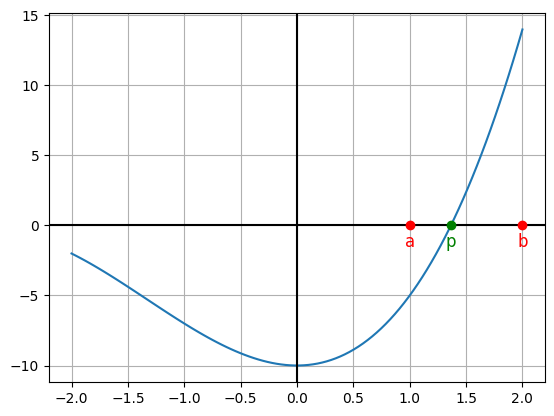

In [ ]:
#Veamos una gráfica de la función que iteramos
import numpy as np
import matplotlib.pyplot as plt

#Impresión de la funcion
xx=np.linspace(-2,2,100)
plt.plot(xx,f(xx))

#Impresión de los ejes
plt.axhline(0, color='black')  # Eje X
plt.axvline(0, color='black')  # Eje Y

#Impresion de los puntos
plt.plot(a0,0,'ro') #Punto incial a
plt.plot(b0,0,'ro') #Punto incial b
plt.plot(p,0,'go') #Aproximacion obtenida

#Rotulos
plt.text(a0, -1.5, 'a', color='red', fontsize=12, ha='center')
plt.text(b0, -1.5, 'b', color='red', fontsize=12, ha='center')
plt.text(p, -1.5, 'p', color='green', fontsize=12, ha='center')

#Cuadricula
plt.grid()

<font size="3" face="Georgia">
Cómo podemos observar al ir dividiendo el intervalo a la mitad se va aproximando a una raíz $p$ dentro del intervalo dado y nos garantiza encontrar una solución con la precisión deseada, a pesar de ello este método es lento ya que se necesitan bastantes iteraciones para conseguir una buena aproximación.
</font>